In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("spam.csv")

In [3]:
df['Category'].value_counts()

Category
ham     4825
spam     747
Name: count, dtype: int64

In [4]:
df.shape

(5572, 2)

## 1.Data Cleaning 


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [6]:
df.sample(5)

,Category,Message
2110,ham,Lara said she can loan me &lt;#&gt; .
5091,ham,No no. I will check all rooms befor activities
4799,ham,Just come home. I don't want u to be miserable
606,ham,TaKe CaRE n gET WeLL sOOn
678,ham,"Piggy, r u awake? I bet u're still sleeping. I..."


In [7]:
df.rename(columns={"Category":"target","Message":"text"},inplace=True)

In [8]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()

In [9]:
df['target']=encoder.fit_transform(df['target'])

In [10]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
# check for missing values
df.isnull().sum()

target    0
text      0
dtype: int64

In [12]:
#check for duplicates
df.duplicated().sum()

np.int64(415)

In [13]:
df.drop_duplicates(keep='first')

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ã¼ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


## 2.EDA

In [14]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [15]:
df['target'].value_counts()

target
0    4825
1     747
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x20e8e1e0050>,
 [Text(-1.0038715425384215, 0.4497131597824666, 'ham'),
  Text(1.0038714746336121, -0.44971331136284726, 'spam')],
 [Text(-0.547566295930048, 0.24529808715407267, '86.59'),
  Text(0.5475662588910611, -0.24529816983428027, '13.41')])

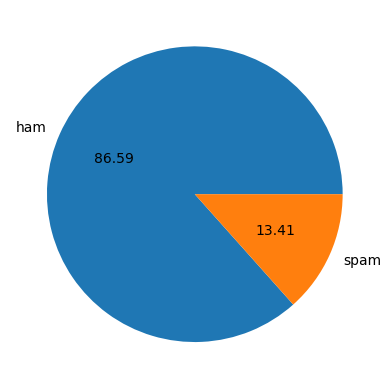

In [16]:
plt.pie(df['target'].value_counts(),labels=["ham","spam"],autopct='%0.2f')

In [17]:
import nltk

In [18]:
# Downloads the basic word/sentence tokenizer
nltk.download('punkt_tab') 

# Useful if you plan to remove "the", "is", "at", etc.
nltk.download('stopwords') 

# Useful if you need to lemmatize (e.g., converting 'running' to 'run')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to C:\Users\venkat
[nltk_data]     kasireddy\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\venkat
[nltk_data]     kasireddy\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\venkat
[nltk_data]     kasireddy\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [19]:
nltk.download("punkt")

[nltk_data] Downloading package punkt to C:\Users\venkat
[nltk_data]     kasireddy\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [20]:
df['num_char']=df['text'].apply(len)

In [21]:
from nltk.tokenize import word_tokenize

In [22]:
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [23]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [24]:
df.head()

,target,text,num_char,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [25]:
df[['num_char','num_words','num_sentences']].describe()

,num_char,num_words,num_sentences
count,5572.000000,5572.000000,5572.000000
mean,80.494616,18.831838,2.004666
std,59.998745,13.866037,1.539516
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,61.000000,15.000000,2.000000
75%,122.000000,27.000000,2.000000
max,910.000000,220.000000,38.000000


In [26]:
df[df['target']==0][['num_char','num_words','num_sentences']].describe()

,num_char,num_words,num_sentences
count,4825.000000,4825.000000,4825.000000
mean,71.524767,17.431088,1.846010
std,58.453847,14.133054,1.475377
min,2.000000,1.000000,1.000000
25%,33.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,93.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [27]:
df[df['target']==1][['num_char','num_words','num_sentences']].describe()

,num_char,num_words,num_sentences
count,747.000000,747.000000,747.000000
mean,138.432396,27.879518,3.029451
std,30.105608,7.036972,1.552198
min,7.000000,2.000000,1.000000
25%,133.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_char', ylabel='Count'>

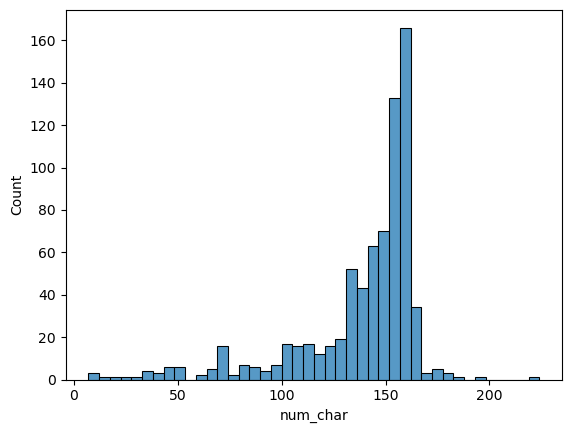

In [28]:
sns.histplot(df[df['target']==1]['num_char'])

<Axes: xlabel='num_char', ylabel='Count'>

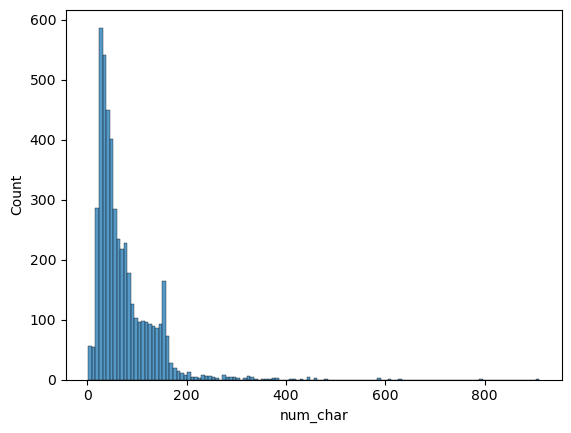

In [29]:
sns.histplot(df[df['target']==0]['num_char'])

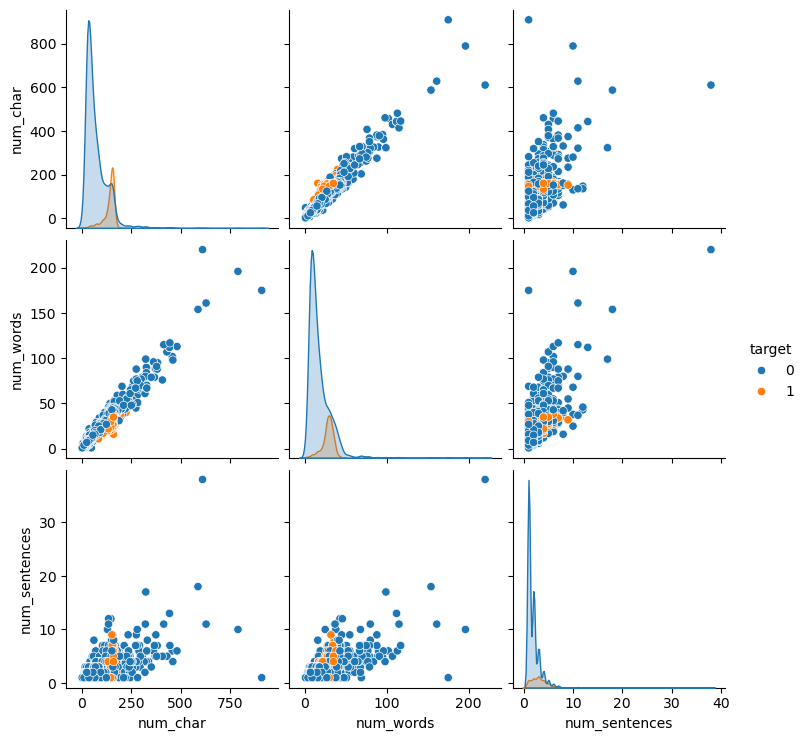

In [30]:
sns.pairplot(df,hue='target')

<Axes: >

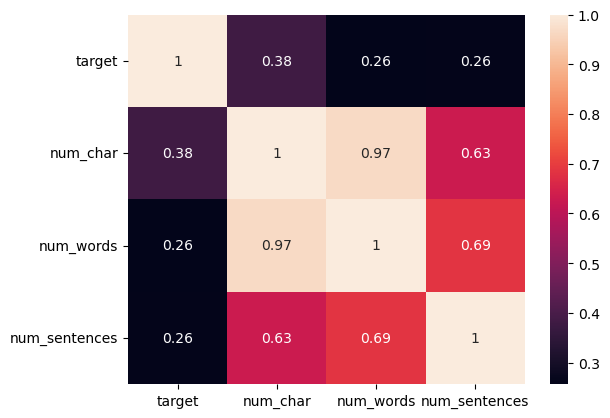

In [31]:
sns.heatmap(df[['target','num_char','num_words','num_sentences']].corr(),annot=True)

## 3. data preprocessing

In [32]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [33]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()

In [34]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [35]:
def transform_text(text):
    text=text.lower()
    text=nltk.word_tokenize(text)
    y=[]
    for i in text:
        if i.isalnum():
            y.append(i)
    text=y[:]
    y.clear()
    for i in text:
        if i not in stopwords.words("english") :
            y.append(i)
    text=y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i))
    
    return " ".join(y)

In [36]:
transform_text("did you liking my presentation on ml?")

'like present ml'

In [37]:
df['transformed_text'] = df['text'].apply(transform_text)


In [38]:
df.head()

,target,text,num_char,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [39]:
pip install wordcloud


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [40]:
from wordcloud import WordCloud
wc=WordCloud(width=1000,height=1000,min_font_size=10,background_color='white')

In [41]:
spam_wc=wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=''))

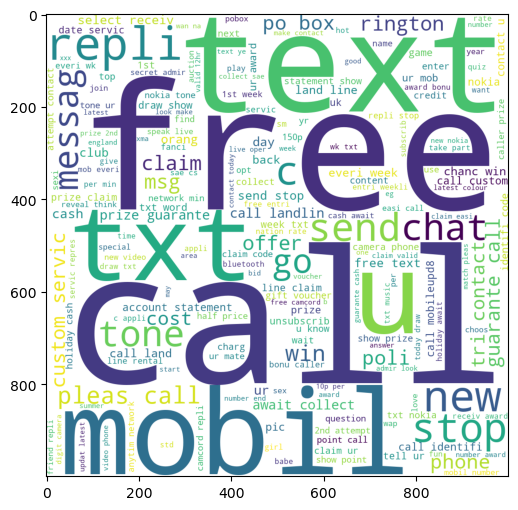

In [42]:
plt.figure(figsize=(16,6))
plt.imshow(spam_wc)

In [43]:
ham_wc=wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=''))

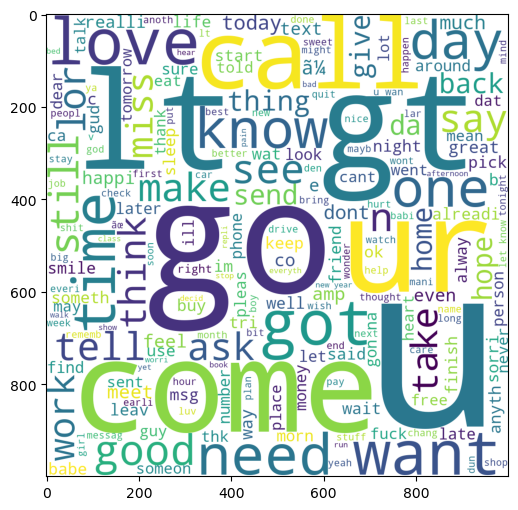

In [44]:
plt.figure(figsize=(16,6))
plt.imshow(ham_wc)

In [45]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

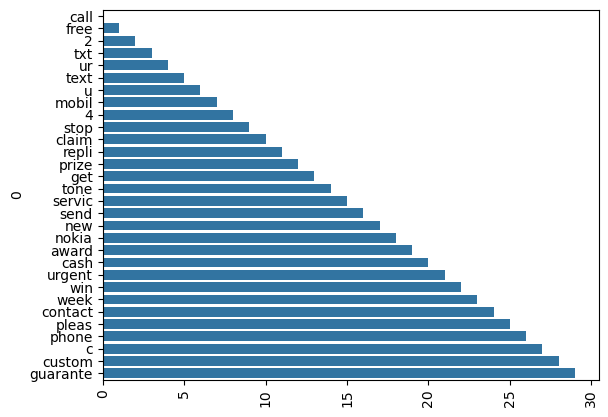

In [46]:
from collections import Counter
sns.barplot(pd.DataFrame(Counter(spam_corpus).most_common(30))[0])
plt.xticks(rotation='vertical')
plt.show()

## 4. model building

In [47]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv=CountVectorizer()
tf=TfidfVectorizer()

In [48]:
X=tf.fit_transform(df['transformed_text']).toarray()

In [49]:
Y=df['target'].values

In [50]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=2)

In [51]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [52]:
gnb.fit(x_train,y_train)
y_pred1=gnb.predict(x_test)
print('accuracy :',accuracy_score(y_test,y_pred1))
print('precision  :',precision_score(y_test,y_pred1))
print('confusion matrix :',confusion_matrix(y_test,y_pred1))

accuracy : 0.8600896860986547
precision  : 0.5038759689922481
confusion matrix : [[829 128]
 [ 28 130]]


In [53]:
mnb.fit(x_train,y_train)
y_pred1=mnb.predict(x_test)
print('accuracy :',accuracy_score(y_test,y_pred1))
print('precision  :',precision_score(y_test,y_pred1))
print('confusion matrix :',confusion_matrix(y_test,y_pred1))

accuracy : 0.95695067264574
precision  : 1.0
confusion matrix : [[957   0]
 [ 48 110]]


In [54]:
bnb.fit(x_train,y_train)
y_pred1=bnb.predict(x_test)
print('accuracy :',accuracy_score(y_test,y_pred1))
print('precision  :',precision_score(y_test,y_pred1))
print('confusion matrix :',confusion_matrix(y_test,y_pred1))

accuracy : 0.9623318385650225
precision  : 0.9603174603174603
confusion matrix : [[952   5]
 [ 37 121]]


### testing all models for better result

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [56]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [57]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [58]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [59]:
train_classifier(etc,x_train,y_train,x_test,y_test)

(0.9704035874439462, 1.0)

In [74]:
accuracy_scores = []
precision_scores = []
  
for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, x_train,y_train,x_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.967713004484305
Precision -  0.9552238805970149


C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

For  KN
Accuracy -  0.895067264573991
Precision -  1.0
For  NB
Accuracy -  0.95695067264574
Precision -  1.0
For  DT
Accuracy -  0.9282511210762332
Precision -  0.8145161290322581
For  LR
Accuracy -  0.9524663677130045
Precision -  0.9338842975206612
For  RF
Accuracy -  0.9695067264573991
Precision -  1.0
For  AdaBoost
Accuracy -  0.9183856502242153
Precision -  0.9135802469135802
For  BgC
Accuracy -  0.9560538116591928
Precision -  0.8562091503267973
For  ETC
Accuracy -  0.9704035874439462
Precision -  1.0
For  GBDT
Accuracy -  0.9497757847533632
Precision -  0.9473684210526315
For  xgb
Accuracy -  0.9641255605381166
Precision -  0.9338235294117647


In [75]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [76]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.895067,1.000000
2,NB,0.956951,1.000000
5,RF,0.969507,1.000000
8,ETC,0.970404,1.000000
0,SVC,0.967713,0.955224
9,GBDT,0.949776,0.947368
4,LR,0.952466,0.933884
10,xgb,0.964126,0.933824
6,AdaBoost,0.918386,0.913580
7,BgC,0.956054,0.856209


In [61]:
from sklearn.ensemble import VotingClassifier
vc=VotingClassifier(estimators=[("etc",etc),("rfc",rfc),("mnb",mnb)],voting='soft')
vc.fit(x_train,y_train)
y_pred=vc.predict(x_test)

In [63]:
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [69]:
print(accuracy_score(y_test,y_pred))
print(precision_score(y_test,y_pred))

0.9695067264573991
1.0


In [70]:
from sklearn.ensemble import StackingClassifier
stk=StackingClassifier(estimators=[("etc",etc),("rfc",rfc),("mnb",mnb)],final_estimator=rfc)
stk.fit(x_train,y_train)
y_pred=stk.predict(x_test)

In [71]:
print(accuracy_score(y_test,y_pred))
print(precision_score(y_test,y_pred))

0.97847533632287
0.9652777777777778


In [73]:
import pickle
pickle.dump(tf,open("vectorizer.pkl","wb"))
pickle.dump(vc,open("model.pkl","wb"))